# Tarefa 1: 
Colete mais quatro vezes `in_accel_z_raw` nesta posição. Por hipótese, o valor de cada medida é o valor real da aceleração da gravidade somado a um viés e um erro aleatório de média nula. Supondo que o viés tenha se mantido constante entre as medidas, a diferença corresponde à flutuação natural do erro e à mudança de orientação da IMU. Supondo agora que o eixo $z$ esteja bem próximo da vertical, a diferença entre as medidas nas duas orientações deve ser próxima do dobro da aceleração da gravidade local. Faça este cálculo para a média das 5 amostras que você colheu em cada posição.

Pelas informações registradas nos logs, temos a seguinte organização das amostras das duas posições de z

Escala (scale): 0.000598
Orientação 1 (Positiva, 'para cima'): [16615, 16396, 16644, 16466, 16855]
Orientação 2 (Negativa, 'para baixo'): [-16165, -16119, -16144, -16247, -16324]

In [ ]:
import numpy as np

# Constantes
scale = 0.000598
g_local = 9.786366

# Dados coletados pelo robo
z_raw_orientacao_1 = np.array([16615, 16396, 16644, 16466, 16855])
z_raw_orientacao_2 = np.array([-16165, -16119, -16144, -16247, -16324])

# O cálculo da média das amostras
media_z1 = np.mean(z_raw_orientacao_1)
media_z2 = np.mean(z_raw_orientacao_2)

# O cálculo da diferença das médias, considerando a escala
diferenca = (media_z1 - media_z2) * scale
dobro_da_gravidade = 2 * g_local

print(f"Média Orientação 1: {media_z1}")
print(f"Média Orientação 2: {media_z2}")
print(f"Diferença escalonada obtida: {diferenca:.4f} m/s²")
print(f"Dobro da gravidade local :   {dobro_da_gravidade:.4f} m/s²")

Média Orientação 1: 16595.2
Média Orientação 2: -16199.8
Diferença escalonada obtida: 19.6114 m/s²
Dobro da gravidade local :   19.5727 m/s²


# Tarefa 2:

Verifique como mudan¸cas de orienta¸c˜ao no ve´ıculo modificam as entradas. Determine, olhando para esta sa´ıda (e lembrando que a gravidade equivale a uma acelera¸c˜ao para cima), as orienta¸c˜oes dos eixos x, y e z no m´odulo.

As seguinte configurações do carrinho foram testadas:

P1: Carrinho horizontal com a RaspberryPI 'para cima'.\
P2: Carrinho com a roda direita para baixo. As laterais das rodas direita e esquerda correspondem ao plano horizontal.\
P3: Carrinho com a roda esquerda para baixo. As laterais das rodas direita e esquerda correspondem ao plano horizontal.\
P4: Carrinho horizontal com a RaspberryPI 'para baixo'.\
P5: Bico do carrinho 'para baixo'.\
P6: Bico do carrinho 'para cima'.

Os seguintes exemplos de leituras para cada uma das configurações foram tomadas:

P1: -274    40 16649\
P2: -236 16476  -331\
P3: 29 -16267   -439\
P4: 238   311  -16146\
P5: -16302 -2  3\
P6: 16514   177  -283

A partir destes valores podemos inferir que os eixos da IMU são, aproximadamente:

Eixo z na vertical, normal à placa da IMU e positivo para cima.\
Eixo y no plano 'horizontal' da placa, paralelo ao eixo das rodas, perpendicular a direção de movimento do carrinho e positivo para a esquerda.\
Eixo x no plano 'horizontal' da placa, perpendicular ao eixo das rodas, paralelo a direção de movimento do carrinho e positivo para 'frente'.

# Calibracao da IMU


## 1. Importacoes e parametros

In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import scipy.optimize

scale = 0.000598
g_local = 9.786366  # m/s^2, valor indicado para Sao Paulo na apostila
data_dir = Path("imu_measurements/imu_measurements")

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

## 2. Carregar e combinar as amostras

In [8]:
arquivos = sorted(data_dir.glob("*.npy"))

if not arquivos:
    raise FileNotFoundError(f"Nenhum arquivo .npy encontrado em {data_dir.resolve()}")

leituras = [np.load(arquivo, allow_pickle=False).astype(float) for arquivo in arquivos]
p1, p2, p3, p4, p5, p6 = leituras
todas_as_leituras_plano = np.concatenate((p1, p2, p3, p4, p5, p6), axis=0)

print([arquivo.name for arquivo in arquivos])
print("Formatos individuais:", [leitura.shape for leitura in leituras])
print("Formato combinado:", todas_as_leituras_plano.shape)

['dados_imu_p1.npy', 'dados_imu_p2.npy', 'dados_imu_p3.npy', 'dados_imu_p4.npy', 'dados_imu_p5.npy', 'dados_imu_p6.npy']
Formatos individuais: [(5000, 3), (5000, 3), (5000, 3), (5000, 3), (5000, 3), (5000, 3)]
Formato combinado: (30000, 3)


## 3. Calibracao com escala uniforme

A primeira funcao objetivo estima o vies nos tres eixos e a gravidade, assumindo a mesma escala para todos os eixos.

In [9]:
def costfunc1(x, data, scale):
    vx, vy, vz, g = x
    shifted = data + np.array([vx, vy, vz])
    ri = np.linalg.norm(shifted, axis=1)
    residuals = scale * ri - g
    return np.sum(residuals**2)


def grad_costfunc1(x, data, scale):
    vx, vy, vz, g = x
    shifted = data + np.array([vx, vy, vz])
    ri = np.linalg.norm(shifted, axis=1)
    ri = np.where(ri == 0, np.finfo(float).eps, ri)
    residuals = scale * ri - g

    grad_v = np.sum(2 * scale * (shifted / ri[:, None]) * residuals[:, None], axis=0)
    grad_g = -np.sum(2 * residuals)
    return np.array([grad_v[0], grad_v[1], grad_v[2], grad_g])

### Verificacao do gradiente por diferencas finitas

In [10]:
def finite_difference_gradient(func, x, args=(), eps=1e-6):
    x = np.asarray(x, dtype=float)
    grad = np.zeros_like(x)

    for k in range(len(x)):
        step = np.zeros_like(x)
        step[k] = eps
        grad[k] = (func(x + step, *args) - func(x - step, *args)) / (2 * eps)

    return grad


x_teste1 = np.array([0.0, 0.0, 0.0, 9.8])
grad_analitico1 = grad_costfunc1(x_teste1, todas_as_leituras_plano, scale)
grad_numerico1 = finite_difference_gradient(
    costfunc1,
    x_teste1,
    args=(todas_as_leituras_plano, scale),
)

print("Gradiente analitico:", grad_analitico1)
print("Gradiente numerico: ", grad_numerico1)
print("Diferenca:          ", grad_analitico1 - grad_numerico1)

Gradiente analitico: [   0.72536718    0.73723069    1.7821129  -308.79178236]
Gradiente numerico:  [   0.7253675     0.73723092    1.78211354 -308.79178212]
Diferenca:           [-3.21817065e-07 -2.33581550e-07 -6.44102029e-07 -2.39828751e-07]


In [11]:
res1 = scipy.optimize.minimize(
    costfunc1,
    [0.0, 0.0, 0.0, 9.8],
    (todas_as_leituras_plano, scale),
    jac=grad_costfunc1,
)

print(res1)
print("Parametros [vx, vy, vz, g]:", res1.x)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 6.330301917567045
        x: [-1.100e+02 -1.045e+02 -2.534e+02  9.807e+00]
      nit: 28
      jac: [-2.629e-10 -2.082e-10  1.895e-10 -6.333e-07]
 hess_inv: [[ 1.372e+02 -6.355e-01  6.014e+00 -3.714e-04]
            [-6.355e-01  1.390e+02  1.519e+00 -3.512e-04]
            [ 6.014e+00  1.519e+00  1.390e+02 -1.450e-03]
            [-3.714e-04 -3.512e-04 -1.450e-03  1.623e-05]]
     nfev: 33
     njev: 33
Parametros [vx, vy, vz, g]: [-109.96821543 -104.46026417 -253.36616378    9.80724834]


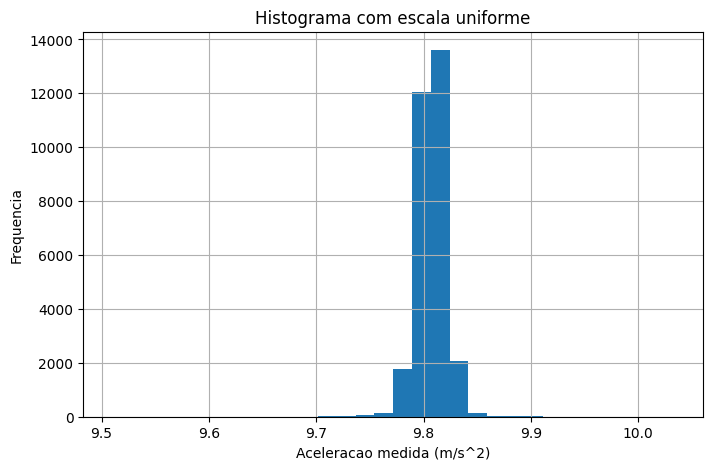

In [12]:
def calc_accel1(medida, parametros, scale):
    rx, ry, rz = medida
    rx += parametros[0]
    ry += parametros[1]
    rz += parametros[2]
    return scale * np.sqrt(rx * rx + ry * ry + rz * rz)


medidas_g = np.array([calc_accel1(m, res1.x, scale) for m in todas_as_leituras_plano])

plt.hist(medidas_g, bins=30)
plt.xlabel("Aceleracao medida (m/s^2)")
plt.ylabel("Frequencia")
plt.title("Histograma com escala uniforme")
plt.show()

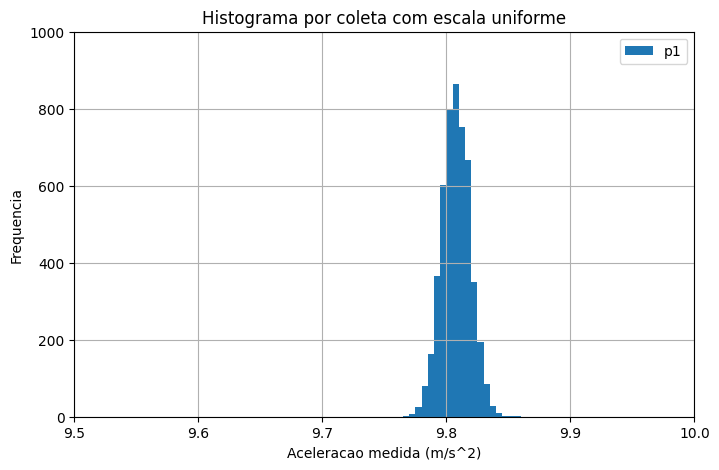

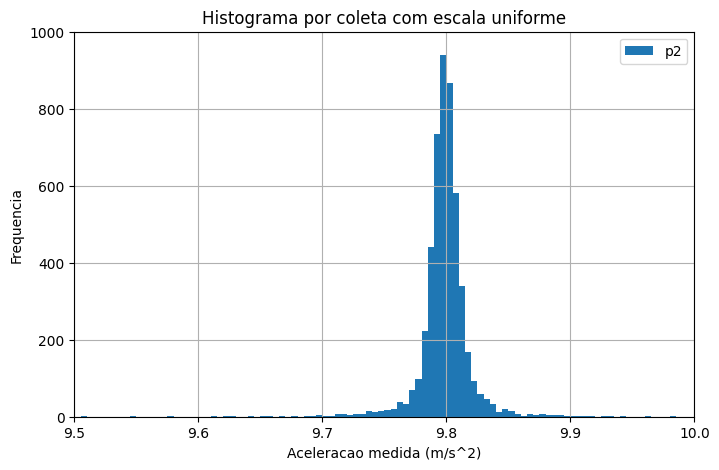

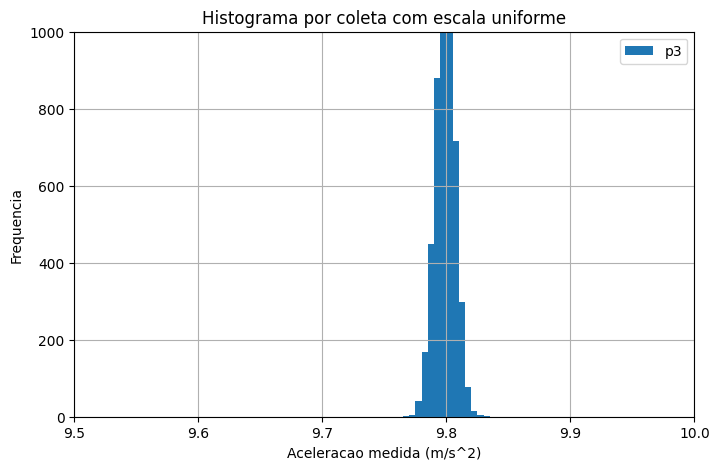

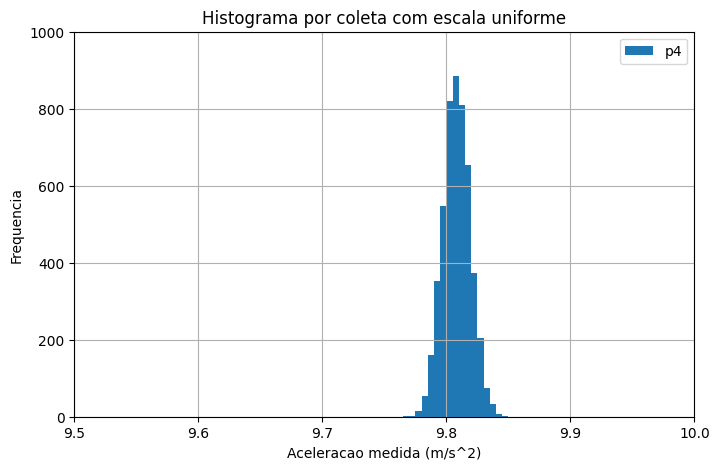

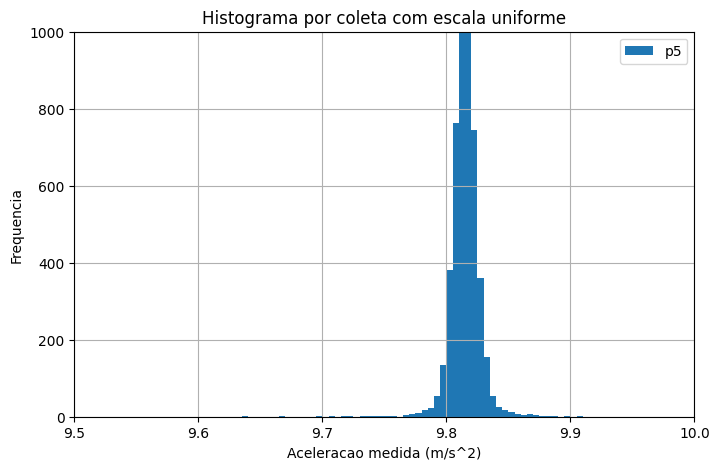

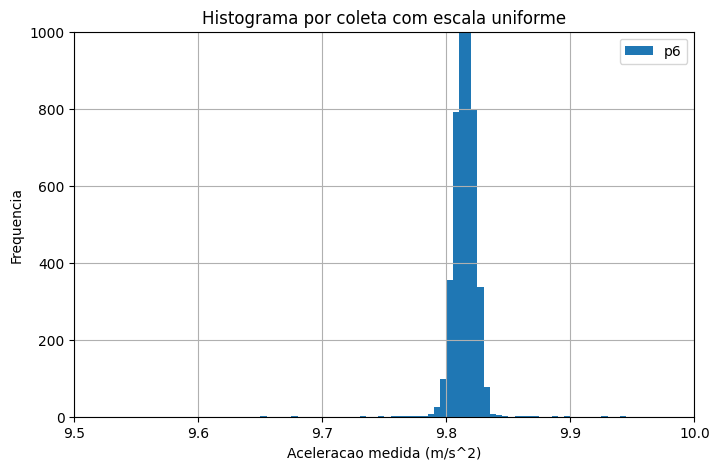

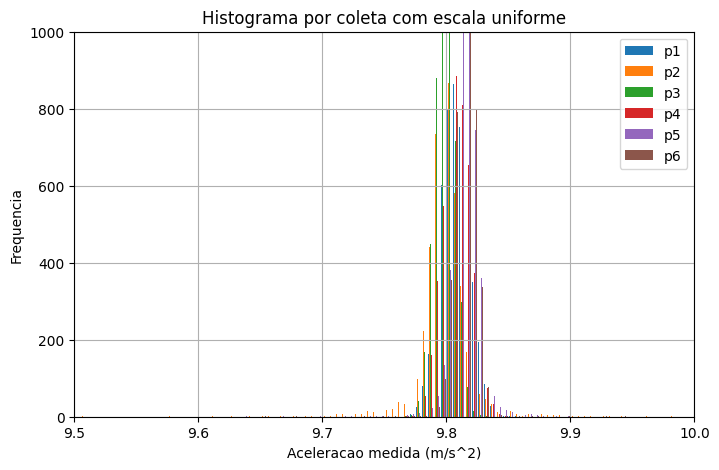

In [13]:
medidas_g_separadas = [
    [calc_accel1(m, res1.x, scale) for m in leitura]
    for leitura in [p1, p2, p3, p4, p5, p6]
]

axis_limits = {
    'x': [9.5, 10],
    'y': [0, 1000]
}

bins = np.linspace(axis_limits["x"][0], axis_limits["x"][1], 101)

for i, medidas in enumerate(medidas_g_separadas, start=1):
    fig, ax = plt.subplots()
    ax.hist(medidas, bins=bins, label=f"p{i}")
    ax.set_xlabel("Aceleracao medida (m/s^2)")
    ax.set_ylabel("Frequencia")
    ax.set_xlim(axis_limits["x"])
    ax.set_ylim(axis_limits["y"])
    ax.set_title("Histograma por coleta com escala uniforme")
    ax.legend()

fig, ax = plt.subplots()
ax.hist(medidas_g_separadas, bins=bins, label=["p1", "p2", "p3", "p4", "p5", "p6"])
ax.set_xlabel("Aceleracao medida (m/s^2)")
ax.set_ylabel("Frequencia")
ax.set_xlim(axis_limits["x"])
ax.set_ylim(axis_limits["y"])
ax.set_title("Histograma por coleta com escala uniforme")
ax.legend()
plt.show()

## 4. Calibracao com ganhos independentes por eixo

Agora o valor de `g` e fixado em `g_local`, e a otimizacao estima vieses e ganhos relativos `sx`, `sy`, `sz`.

In [14]:
def costfunc2(x, data, g, scale):
    vx, vy, vz, sx, sy, sz = x
    shifted = data + np.array([vx, vy, vz])
    scaled = shifted * np.array([sx, sy, sz])
    ri = np.linalg.norm(scaled, axis=1)
    residuals = scale * ri - g
    return np.sum(residuals**2)


def grad_costfunc2(x, data, g, scale):
    vx, vy, vz, sx, sy, sz = x
    shifted = data + np.array([vx, vy, vz])
    gains = np.array([sx, sy, sz])
    ri = np.linalg.norm(shifted * gains, axis=1)
    ri = np.where(ri == 0, np.finfo(float).eps, ri)
    residuals = scale * ri - g

    grad_v = np.sum(
        2 * scale * ((gains**2) * shifted / ri[:, None]) * residuals[:, None],
        axis=0,
    )
    grad_s = np.sum(
        2 * scale * (gains * shifted**2 / ri[:, None]) * residuals[:, None],
        axis=0,
    )

    return np.array([grad_v[0], grad_v[1], grad_v[2], grad_s[0], grad_s[1], grad_s[2]])

In [15]:
x_teste2 = np.array([res1.x[0], res1.x[1], res1.x[2], 1.0, 1.0, 1.0])
grad_analitico2 = grad_costfunc2(x_teste2, todas_as_leituras_plano, g_local, scale)
grad_numerico2 = finite_difference_gradient(
    costfunc2,
    x_teste2,
    args=(todas_as_leituras_plano, g_local, scale),
)

print("Gradiente analitico:", grad_analitico2)
print("Gradiente numerico: ", grad_numerico2)
print("Diferenca:          ", grad_analitico2 - grad_numerico2)

Gradiente analitico: [-5.27133243e-03  8.30088636e-04 -1.37511822e-02  5.60561563e+03
  2.44872613e+03  4.24621415e+03]
Gradiente numerico:  [-5.27133714e-03  8.30084446e-04 -1.37511886e-02  5.60561563e+03
  2.44872613e+03  4.24621415e+03]
Diferenca:           [4.71454323e-09 4.19076892e-09 6.48191105e-09 1.33401045e-07
 7.43339115e-08 9.28221198e-08]


In [16]:
res2 = scipy.optimize.minimize(
    costfunc2,
    [res1.x[0], res1.x[1], res1.x[2], 1.0, 1.0, 1.0],
    (todas_as_leituras_plano, g_local, scale),
    jac=grad_costfunc2,
)

print(res2)
print("Parametros [vx, vy, vz, sx, sy, sz]:", res2.x)

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 5.012681543180392
        x: [-1.098e+02 -1.045e+02 -2.530e+02  9.971e-01  9.987e-01
             9.978e-01]
      nit: 26
      jac: [ 8.048e-08 -3.265e-07 -4.334e-08  6.341e-06  2.783e-06
             4.803e-06]
 hess_inv: [[ 1.321e+02  3.143e+01 ...  1.114e-04  3.818e-05]
            [ 3.143e+01  1.092e+01 ... -1.233e-05  1.331e-05]
            ...
            [ 1.114e-04 -1.233e-05 ...  5.210e-07 -4.959e-09]
            [ 3.818e-05  1.331e-05 ... -4.959e-09  5.131e-07]]
     nfev: 40
     njev: 40
Parametros [vx, vy, vz, sx, sy, sz]: [-109.79370126 -104.46455324 -253.01762059    0.99708971    0.99872567
    0.99779582]


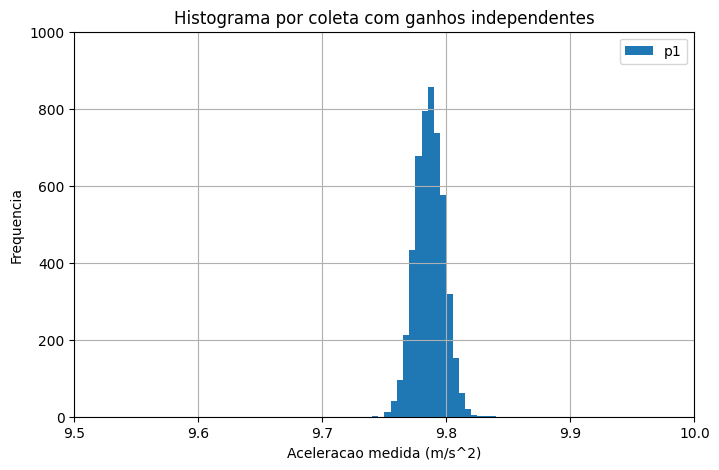

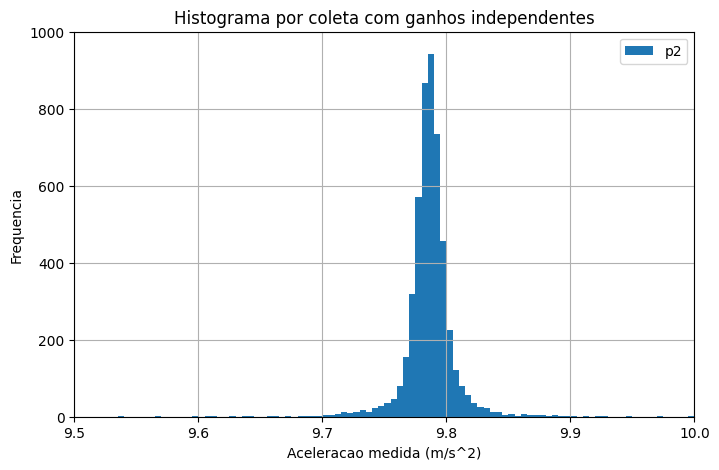

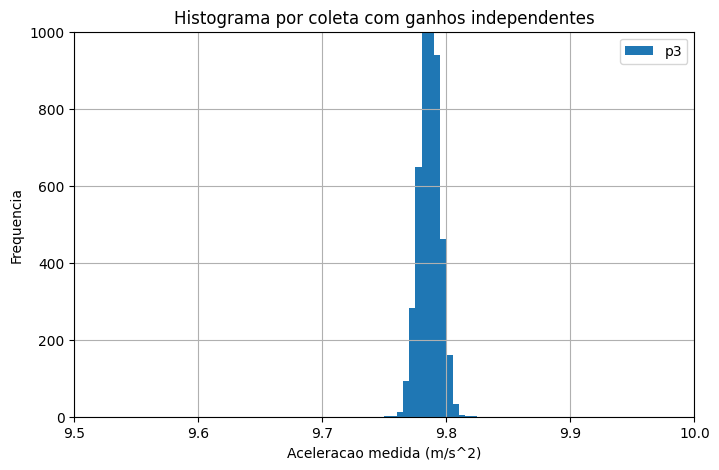

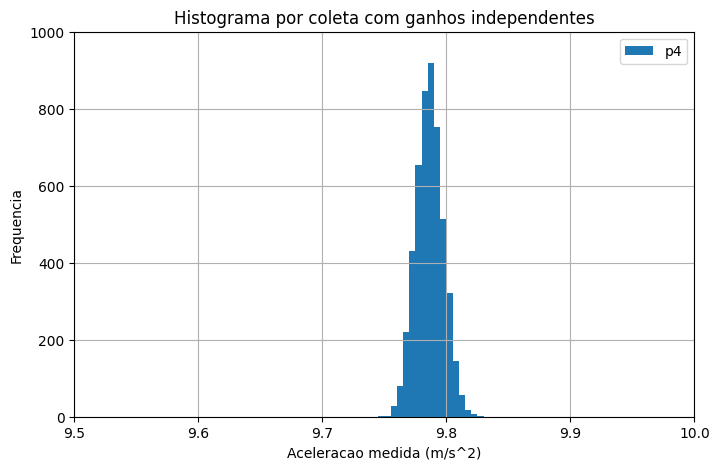

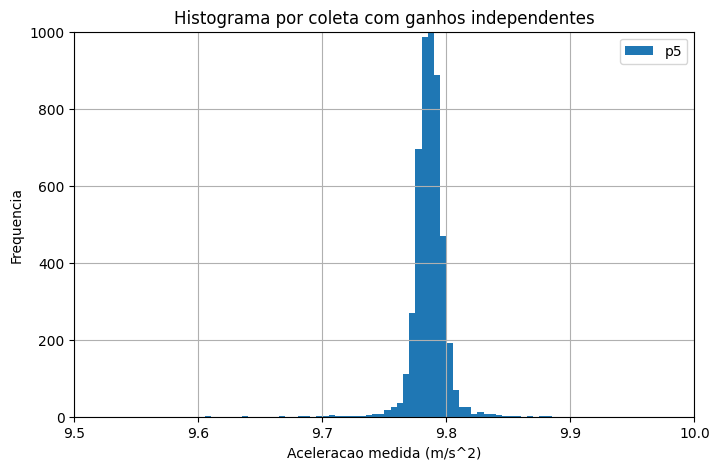

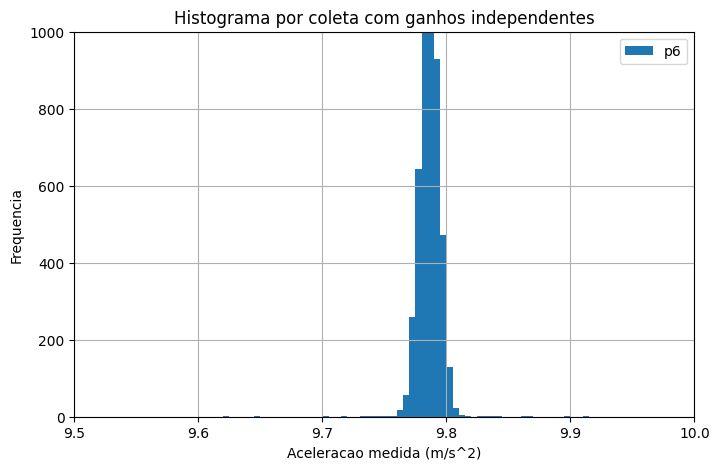

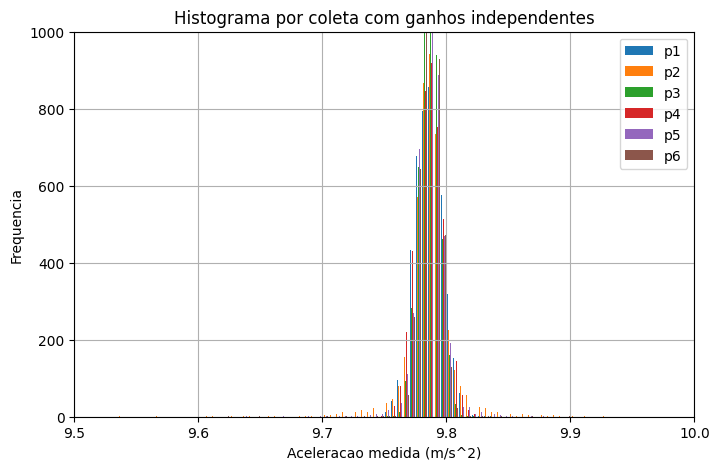

In [18]:
def calc_accel2(medida, parametros, scale):
    rx, ry, rz = medida
    vx, vy, vz, sx, sy, sz = parametros
    rx += vx
    ry += vy
    rz += vz
    rx *= sx
    ry *= sy
    rz *= sz
    return scale * np.sqrt(rx * rx + ry * ry + rz * rz)

medidas_g2 = np.array([
    calc_accel2(m, res2.x, scale)
    for m in todas_as_leituras_plano
])

medidas_g2_separadas = [
    [calc_accel2(m, res2.x, scale) for m in leitura]
    for leitura in [p1, p2, p3, p4, p5, p6]
]

axis_limits = {
    "x": [9.5, 10],
    "y": [0, 1000],
}

bins = np.linspace(axis_limits["x"][0], axis_limits["x"][1], 101)

for i, medidas in enumerate(medidas_g2_separadas, start=1):
    fig, ax = plt.subplots()
    ax.hist(medidas, bins=bins, label=f"p{i}")
    ax.set_xlabel("Aceleracao medida (m/s^2)")
    ax.set_ylabel("Frequencia")
    ax.set_xlim(axis_limits["x"])
    ax.set_ylim(axis_limits["y"])
    ax.set_title("Histograma por coleta com ganhos independentes")
    ax.legend()

fig, ax = plt.subplots()
ax.hist(
    medidas_g2_separadas,
    bins=bins,
    label=["p1", "p2", "p3", "p4", "p5", "p6"],
)
ax.set_xlabel("Aceleracao medida (m/s^2)")
ax.set_ylabel("Frequencia")
ax.set_xlim(axis_limits["x"])
ax.set_ylim(axis_limits["y"])
ax.set_title("Histograma por coleta com ganhos independentes")
ax.legend()
plt.show()

# Tarefa 3:
Qual eixo tem o maior ganho? Qual eixo tem o menor ganho? Qual a diferença entre os ganhos máximo e mínimo?

In [19]:
ganhos = {
    "x": res2.x[3],
    "y": res2.x[4],
    "z": res2.x[5],
}

eixo_maior_ganho = max(ganhos, key=ganhos.get)
eixo_menor_ganho = min(ganhos, key=ganhos.get)
diferenca_ganhos = ganhos[eixo_maior_ganho] - ganhos[eixo_menor_ganho]


print("Ganhos:")
for eixo, ganho in ganhos.items():
    print(f"  s{eixo} = {ganho:.9f}")

print(f"\n1. Maior ganho: eixo {eixo_maior_ganho}; menor ganho: eixo {eixo_menor_ganho}")
print(f"   Diferenca entre maximo e minimo: {diferenca_ganhos:.9f}")


Ganhos:
  sx = 0.997089710
  sy = 0.998725666
  sz = 0.997795824

1. Maior ganho: eixo y; menor ganho: eixo x
   Diferenca entre maximo e minimo: 0.001635956


# Tarefa 4:
Qual o valor do desvio padrão das acelerações em medidas_g2?

In [20]:
desvio_padrao = np.std(medidas_g2, ddof=1)
media = np.mean(medidas_g2)
desvio_relativo = desvio_padrao / media

print(f"2. Desvio padrao de medidas_g2: {desvio_padrao:.9f} m/s^2")

2. Desvio padrao de medidas_g2: 0.012926510 m/s^2


# Tarefa 5:
Qual o valor do desvio relativo, ou seja a razão entre o desvio padrão
e a média de medidas_g2?

In [21]:
media = np.mean(medidas_g2)
desvio_relativo = desvio_padrao / media
print(f"3. Desvio relativo: {desvio_relativo:.9f} ({100 * desvio_relativo:.4f}%)")

3. Desvio relativo: 0.001320872 (0.1321%)
